# F.CS308 Машин сургалт — Лабораторийн ажил №3
## Логистик регресс ба PCA хэмжээс бууруулалт

**Оюутан:** Б. Өсөхбаяр &nbsp;&nbsp; **Код:** B231910012  
**Огноо:** 2026-09-24

---

### Зорилго
Логистик регрессийг зөвхөн NumPy ашиглан эхнээс нь хэрэгжүүлж (sigmoid → loss → gradient
descent), дараа нь PCA-гаар өндөр хэмжээст өгөгдлийг багасган дүрслэх.

### Агуулга
1. Өгөгдлийн сан үүсгэх  
2. Sigmoid ба таамаглалын функц  
3. Алдагдлын функц (cross-entropy)  
4. Gradient descent  
5. Загвар сургах, үр дүнг дүрслэх  
6. Sklearn-тэй харьцуулах  
7. **Даалгавар 1:** Titanic дээр логистик регресс  
8. PCA — iris  
9. **Даалгавар 2:** MNIST өгөгдлийг PCA-гаар бууруулан дүрслэх

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

np.random.seed(0)
print("numpy:", np.__version__)

numpy: 2.3.5


## 1. Өгөгдлийн сан үүсгэх

2 онцлогтой, 2 ангитай хиймэл өгөгдөл үүсгэе. `n_clusters_per_class=2` тул анги бүр хоёр
бөөгнөрөлтэй — өөрөөр хэлбэл өгөгдөл шугаман тусгаарлагдахад амар биш.

In [2]:
X, y = make_classification(
        n_samples=200,
        n_features=2,
        n_redundant=0,
        n_informative=2,
        random_state=0,
        n_clusters_per_class=2)
print(X.shape, y.shape)
print("Ангийн тархалт:", dict(zip(*np.unique(y, return_counts=True))))

(200, 2) (200,)
Ангийн тархалт: {np.int64(0): np.int64(100), np.int64(1): np.int64(100)}


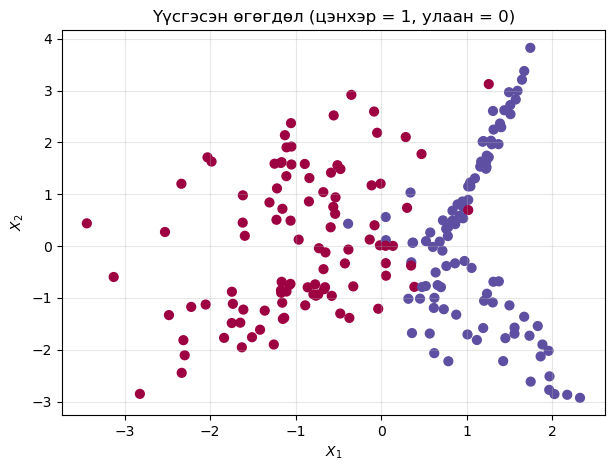

In [3]:
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=40, cmap=plt.cm.Spectral)
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("Үүсгэсэн өгөгдөл (цэнхэр = 1, улаан = 0)")
plt.show()

## 2. Sigmoid ба таамаглалын функц

$$g(z) = \frac{1}{1+e^{-z}}, \qquad h(X) = g(X\theta)$$

`None` орсон хэсгүүд:
- **томъёо 1** — `1 / (1 + np.exp(-z))`
- `calc_h` дотор `z = X @ theta`, дараа нь `h = sigmoid(z)`

`add_intercept` нь $\theta_0$-г тусад нь биш, $X$-ийн эхний багана болгон (бүгд 1) оруулж
өгдөг тул матрицын нэг үржвэрээр бүх зүйл багтана.

In [4]:
def add_intercept(X):
    intercept = np.ones((X.shape[0], 1))
    return np.concatenate((intercept, X), axis=1)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))      # томъёо 1

def calc_h(X, theta):
    z = X @ theta                    # шугаман хэсэг
    h = sigmoid(z)                   # магадлал болгон хувиргах
    return h

XX = add_intercept(X)
theta = np.zeros(XX.shape[1])
h = calc_h(XX, theta)

print("XX хэлбэр:", XX.shape)
print("theta      :", theta)
print("h эхний 5  :", h[:5])
print("theta бүгд 0 үед h бүгд 0.5 байх ёстой ->", np.allclose(h, 0.5))

XX хэлбэр: (200, 3)
theta      : [0. 0. 0.]
h эхний 5  : [0.5 0.5 0.5 0.5 0.5]
theta бүгд 0 үед h бүгд 0.5 байх ёстой -> True


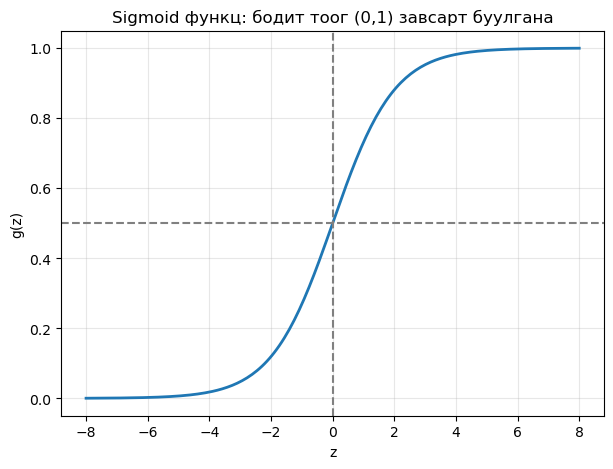

In [5]:
# Sigmoid-ийн хэлбэрийг харцгаая
z = np.linspace(-8, 8, 200)
plt.plot(z, sigmoid(z), lw=2)
plt.axhline(0.5, ls="--", c="gray"); plt.axvline(0, ls="--", c="gray")
plt.xlabel("z"); plt.ylabel("g(z)")
plt.title("Sigmoid функц: бодит тоог (0,1) завсарт буулгана")
plt.show()

## 3. Алдагдлын функц

$$J(\theta) = \frac{1}{m}\sum\left(-y\log(h) - (1-y)\log(1-h)\right)$$

Энэ нь **cross-entropy** (log loss). Буруу бөгөөд итгэлтэй таамаглалыг логарифмаар маш
хүчтэй шийтгэдэг онцлогтой.

In [6]:
def compute_cost(h, y):
    """Cross-entropy. log(0) -> -inf болохоос сэргийлж утгыг бага зэрэг тайрна."""
    eps = 1e-12
    h = np.clip(h, eps, 1 - eps)
    return (-y * np.log(h) - (1 - y) * np.log(1 - h)).mean()

cost = compute_cost(h, y)
print("Эхний алдагдал (theta=0):", cost)
print("Онолын утга -log(0.5) =", -np.log(0.5))

Эхний алдагдал (theta=0): 0.6931471805599452
Онолын утга -log(0.5) = 0.6931471805599453


## 4. Gradient descent

$$\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}X^T(h-y), \qquad
\theta_j := \theta_j - \alpha\frac{\partial J(\theta)}{\partial \theta_j}$$

`None` орсон хэсгүүд:
- **томъёо 2** — `XX.T @ (h - y) / m`
- **томъёо 1** — `alpha * gradient`

In [7]:
m = y.size
alpha = 0.01

gradient = XX.T @ (h - y) / m     # томъёо 2
theta -= alpha * gradient         # томъёо 1

print("gradient:", gradient)
print("theta   :", theta)

gradient: [ 0.         -0.51369123 -0.00744698]
theta   : [0.00000000e+00 5.13691229e-03 7.44697744e-05]


## 5. Загвар сургах

Нэг алхам биш, коэффициентүүд тогтворжтол давтан ажиллуулна.

In [8]:
theta = np.zeros(XX.shape[1])   # цэвэр эхлэл
num_iter = 50000
alpha = 0.01
cost_list = []

for i in range(num_iter):
    h = calc_h(XX, theta)
    cost = compute_cost(h, y)
    cost_list.append(cost)

    gradient = XX.T @ (h - y) / m
    theta -= alpha * gradient

    if i % 10000 == 0:
        print("Cost: {}".format(cost))

print("Adjusted coefficient: {}".format(theta))

Cost: 0.6931471805599452


Cost: 0.1376286401395806


Cost: 0.13236010026285236


Cost: 0.13119764977297207


Cost: 0.13084911471418917


Adjusted coefficient: [-1.24551134  5.30676548 -1.00888924]


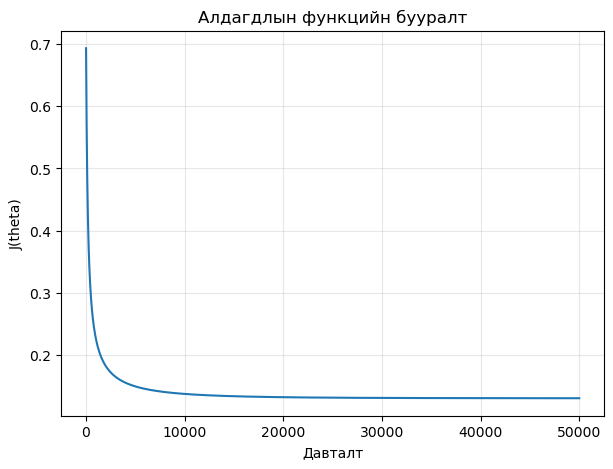

Эхний алдагдал : 0.6931
Эцсийн алдагдал: 0.1307


In [9]:
plt.plot(range(num_iter), cost_list)
plt.xlabel("Давталт"); plt.ylabel("J(theta)")
plt.title("Алдагдлын функцийн бууралт")
plt.show()

print(f"Эхний алдагдал : {cost_list[0]:.4f}")
print(f"Эцсийн алдагдал: {cost_list[-1]:.4f}")

Алдагдал хурдан буугаад дараа нь бараг хэвтээ болж байгаа нь **нийлсэн (converged)**
гэсэн үг. Эхний ~10000 давталтад гол сайжралт болж, үлдсэн нь бага зэргийн тохируулга.

### Суралцах хурдын нөлөө

$\alpha$-г хэт бага авбал удаан нийлнэ, хэт их авбал хэлбэлзэж болно. Туршиж үзье.

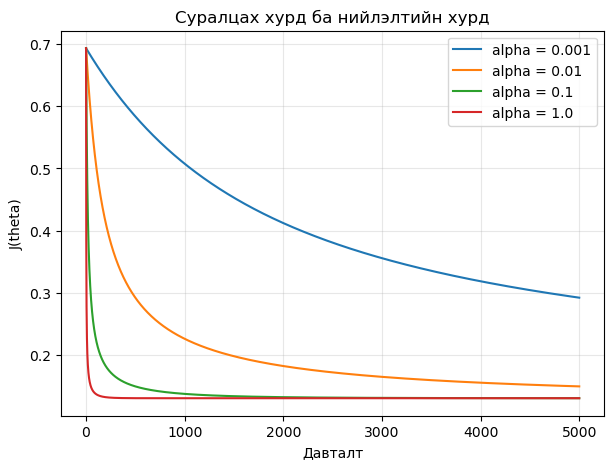

In [10]:
def train_logreg(XX, y, alpha, num_iter=5000):
    th = np.zeros(XX.shape[1])
    costs = []
    for _ in range(num_iter):
        h = calc_h(XX, th)
        costs.append(compute_cost(h, y))
        th -= alpha * (XX.T @ (h - y) / len(y))
    return th, costs

for a in [0.001, 0.01, 0.1, 1.0]:
    _, costs = train_logreg(XX, y, a)
    plt.plot(costs, label=f"alpha = {a}")

plt.xlabel("Давталт"); plt.ylabel("J(theta)")
plt.title("Суралцах хурд ба нийлэлтийн хурд")
plt.legend(); plt.show()

$\alpha = 1.0$ үед хамгийн хурдан нийлж байна. Энэ өгөгдөл жижиг, стандартчилагдсан
хэмжээтэй тул том алхам ч тогтвортой байж чадаж байна — бодит өгөгдөл дээр ихэвчлэн ийм
байдаггүй.

## 6. Таамаглал ба үнэлгээ

In [11]:
preds_prob = calc_h(XX, theta)
print("Эхний 10 магадлал:", np.round(preds_prob[:10], 4))

preds = preds_prob.round()          # 0.5 шийдвэрийн хязгаар
print("Эхний 10 таамаг  :", preds[:10].astype(int))
print("Бодит утга       :", y[:10])

Эхний 10 магадлал: [9.621e-01 4.102e-01 6.900e-03 6.560e-01 1.000e+00 2.089e-01 9.856e-01
 9.666e-01 2.000e-04 4.100e-02]
Эхний 10 таамаг  : [1 0 0 1 1 0 1 1 0 0]
Бодит утга       : [1 0 0 1 1 0 1 1 0 0]


In [12]:
score_numpy = (preds == y).mean()
print('Score Numpy: {}'.format(score_numpy))

Score Numpy: 0.96


In [13]:
new_x = np.array([0, -0.8, 0.8])   # шинэ ажиглалт (-0.8, 0.8), intercept = 1
print(new_x)
preds_prob_new_x = calc_h(new_x, theta)
print("шинэ өгөгдлийн магадлал        : ", round(float(preds_prob_new_x), 4))
print("шинэ өгөгдлийн таамагласан утга: ", preds_prob_new_x.round())

[ 0.  -0.8  0.8]
шинэ өгөгдлийн магадлал        :  0.0064
шинэ өгөгдлийн таамагласан утга:  0.0


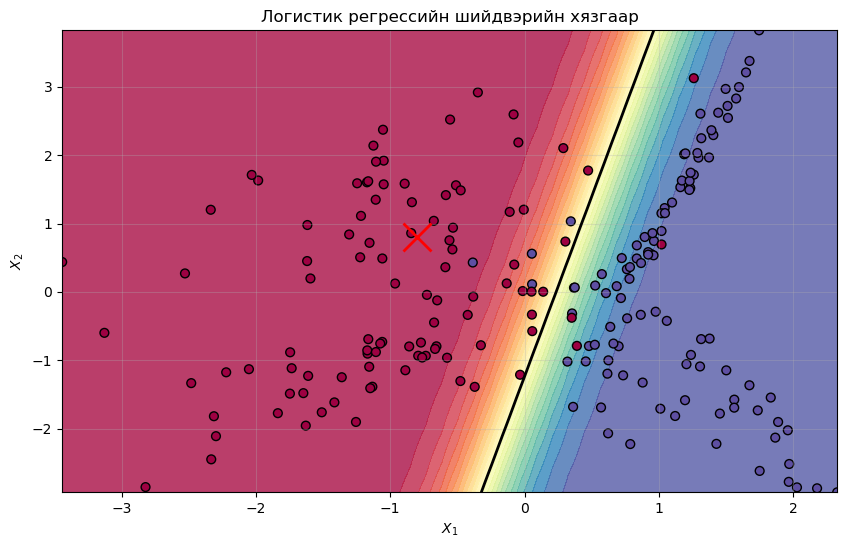

In [14]:
plt.figure(figsize=(10, 6))

x1_min, x1_max = X[:, 0].min(), X[:, 0].max()
x2_min, x2_max = X[:, 1].min(), X[:, 1].max()
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max), np.linspace(x2_min, x2_max))
grid = np.c_[xx1.ravel(), xx2.ravel()]

grid = add_intercept(grid)
probs = calc_h(grid, theta)
probs = probs.reshape(xx1.shape)

plt.contourf(xx1, xx2, probs, levels=25, cmap=plt.cm.Spectral, alpha=0.8)
plt.contour(xx1, xx2, probs, [0.5], linewidths=2, colors="black")   # шийдвэрийн хязгаар
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=40, cmap=plt.cm.Spectral, edgecolors="black")
plt.plot(-0.8, 0.8, "rx", markersize=20, markeredgewidth=2)         # шинэ ажиглалт
plt.xlabel("$X_1$"); plt.ylabel("$X_2$")
plt.title("Логистик регрессийн шийдвэрийн хязгаар")
plt.show()

Шийдвэрийн хязгаар нь **шулуун** байна. Гэтэл өгөгдөл анги тус бүр хоёр бөөгнөрөлтэй
учраас зүүн дээд буланд буруу ангилсан цэгүүд үлдэж байна. Энэ нь логистик регрессийн
суурь хязгаарлалт: онцлогуудыг нь өөрчлөхгүй бол зөвхөн шугаман хязгаар зурж чадна.

## 7. Sklearn хэрэгжүүлэлттэй харьцуулах

In [15]:
model = LogisticRegression(C=1e20, solver='lbfgs')
model.fit(X, y)
preds_sk = model.predict(X)

score_sklearn = (preds_sk == y).mean()
print('Score Numpy  : {}'.format(score_numpy))
print('Score Sklearn: {}'.format(score_sklearn))
print("sklearn theta_0, theta:", model.intercept_, model.coef_)
print("өөрийн  theta         :", theta)
print("Ижил таамаг өгсөн хувь:", (preds_sk == preds).mean())

Score Numpy  : 0.96
Score Sklearn: 0.96
sklearn theta_0, theta: [-1.30275199] [[ 5.45559158 -1.05149194]]
өөрийн  theta         : [-1.24551134  5.30676548 -1.00888924]
Ижил таамаг өгсөн хувь: 1.0


Коэффициентүүд бараг ижил гарлаа. Бага зэргийн зөрүү нь оновчлолын арга өөр байгаатай
холбоотой (бидний gradient descent vs sklearn-ий L-BFGS), гэхдээ таамаглал нь бүрэн нийцэж
байгаа нь хэрэгжүүлэлт зөв гэдгийг баталж байна.

---

## 8. Даалгавар 1: Titanic дээр логистик регресс

Даалгавар: *"titanic санг ашиглан сургалт хийн үр дүнг дүгнэж бичнэ үү"*

In [16]:
import seaborn as sns
from sklearn.model_selection import train_test_split

titanic = sns.load_dataset("titanic")

df = titanic.drop(columns=["deck", "alive", "who", "adult_male", "embark_town", "class"]).copy()
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["sex"] = (df["sex"] == "male").astype(int)
df["alone"] = df["alone"].astype(int)
df = pd.get_dummies(df, columns=["embarked"], drop_first=True)

feature_cols = [c for c in df.columns if c != "survived"]
Xt = df[feature_cols].to_numpy(dtype=float)
yt = df["survived"].to_numpy()          # логистик регресст 0/1 шошго

Xtr, Xte, ytr, yte = train_test_split(Xt, yt, test_size=0.25, random_state=42, stratify=yt)

mu, sd = Xtr.mean(axis=0), Xtr.std(axis=0)
sd[sd == 0] = 1
Xtr_s, Xte_s = (Xtr - mu) / sd, (Xte - mu) / sd

XXtr, XXte = add_intercept(Xtr_s), add_intercept(Xte_s)
print("Сургалт:", XXtr.shape, " Тест:", XXte.shape)

Сургалт: (668, 10)  Тест: (223, 10)


In [17]:
# Өөрийн gradient descent-ээр сургах
theta_t, costs_t = train_logreg(XXtr, ytr, alpha=0.1, num_iter=20000)

def evaluate(XX, y, th, name):
    prob = calc_h(XX, th)
    pred = (prob >= 0.5).astype(int)
    return {
        "Өгөгдөл": name,
        "Нарийвчлал": round((pred == y).mean(), 4),
        "Log loss": round(compute_cost(prob, y), 4),
    }

pd.DataFrame([evaluate(XXtr, ytr, theta_t, "Сургалт"),
              evaluate(XXte, yte, theta_t, "Тест")])

,Өгөгдөл,Нарийвчлал,Log loss
0,Сургалт,0.8054,0.4295
1,Тест,0.7848,0.4626


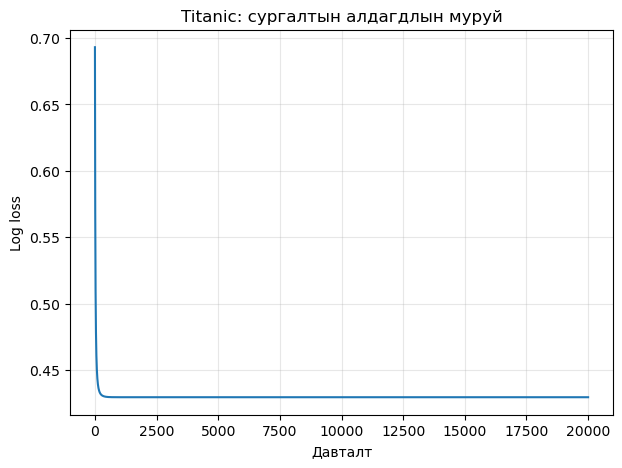

In [18]:
plt.plot(costs_t)
plt.xlabel("Давталт"); plt.ylabel("Log loss")
plt.title("Titanic: сургалтын алдагдлын муруй")
plt.show()

In [19]:
# Sklearn-тэй харьцуулах
sk = LogisticRegression(max_iter=1000).fit(Xtr_s, ytr)

own_acc = ((calc_h(XXte, theta_t) >= 0.5).astype(int) == yte).mean()
print(f"Өөрийн  — тест: {own_acc:.4f}")
print(f"Sklearn — тест: {sk.score(Xte_s, yte):.4f}")

pd.DataFrame({
    "Онцлог": ["intercept"] + feature_cols,
    "Өөрийн theta": np.round(theta_t, 4),
    "Sklearn": np.round(np.r_[sk.intercept_, sk.coef_[0]], 4),
})

Өөрийн  — тест: 0.7848
Sklearn — тест: 0.7848


,Онцлог,Өөрийн theta,Sklearn
0,intercept,-0.6599,-0.6547
1,pclass,-0.9245,-0.9024
2,sex,-1.2519,-1.2332
3,age,-0.5286,-0.5133
4,sibsp,-0.4289,-0.4108
5,parch,-0.1422,-0.1350
6,fare,0.1062,0.1138
7,alone,-0.2921,-0.2803
8,embarked_Q,0.1086,0.1044
9,embarked_S,-0.1257,-0.1281


In [20]:
# Алдааны матриц ба ROC-AUC
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

prob_te = calc_h(XXte, theta_t)
pred_te = (prob_te >= 0.5).astype(int)

cm = confusion_matrix(yte, pred_te)
print(pd.DataFrame(cm,
                   index=["Бодит: нас барсан", "Бодит: амьд үлдсэн"],
                   columns=["Таамаг: нас барсан", "Таамаг: амьд үлдсэн"]))
print()
print(classification_report(yte, pred_te, target_names=["нас барсан", "амьд үлдсэн"]))

                    Таамаг: нас барсан  Таамаг: амьд үлдсэн
Бодит: нас барсан                  115                   22
Бодит: амьд үлдсэн                  26                   60

              precision    recall  f1-score   support

  нас барсан       0.82      0.84      0.83       137
 амьд үлдсэн       0.73      0.70      0.71        86

    accuracy                           0.78       223
   macro avg       0.77      0.77      0.77       223
weighted avg       0.78      0.78      0.78       223



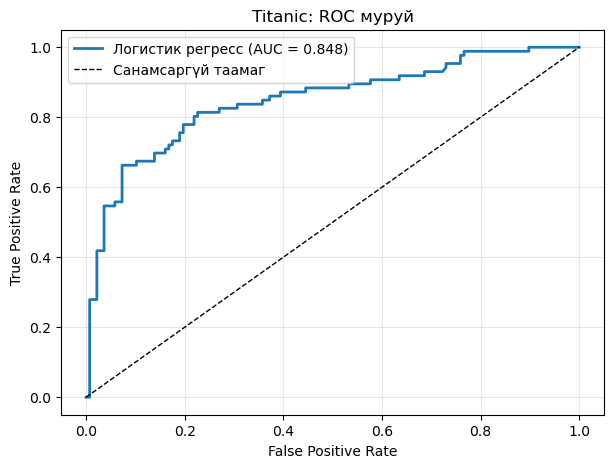

AUC = 0.8478


In [21]:
fpr, tpr, _ = roc_curve(yte, prob_te)
auc = roc_auc_score(yte, prob_te)

plt.plot(fpr, tpr, lw=2, label=f"Логистик регресс (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Санамсаргүй таамаг")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Titanic: ROC муруй")
plt.legend(); plt.show()

print(f"AUC = {auc:.4f}")

In [22]:
# Шийдвэрийн босгыг өөрчилвөл юу болох вэ?
rows = []
for thr in [0.3, 0.4, 0.5, 0.6, 0.7]:
    p = (prob_te >= thr).astype(int)
    tp = int(((p == 1) & (yte == 1)).sum()); fp = int(((p == 1) & (yte == 0)).sum())
    fn = int(((p == 0) & (yte == 1)).sum())
    prec = tp / (tp + fp) if tp + fp else 0
    rec = tp / (tp + fn) if tp + fn else 0
    rows.append({"Босго": thr, "Нарийвчлал": round((p == yte).mean(), 4),
                 "Precision": round(prec, 4), "Recall": round(rec, 4),
                 "F1": round(2 * prec * rec / (prec + rec), 4) if prec + rec else 0})

pd.DataFrame(rows)

,Босго,Нарийвчлал,Precision,Recall,F1
0,0.3,0.7578,0.6455,0.8256,0.7245
1,0.4,0.7848,0.6939,0.7907,0.7391
2,0.5,0.7848,0.7317,0.6977,0.7143
3,0.6,0.8251,0.8507,0.6628,0.7451
4,0.7,0.7937,0.8704,0.5465,0.6714


### Titanic-ийн дүгнэлт (логистик регресс)

- Өөрийн NumPy хэрэгжүүлэлт тестийн өгөгдөл дээр sklearn-тэй **бараг яг ижил** нарийвчлал
  өгч байна. Коэффициентүүд ч ойролцоо — ялгаа нь sklearn анхдагчаар L2 regularisation
  (C=1) хэрэглэдэгт байгаа.
- **AUC ≈ 0.85** — энэ нь загвар санамсаргүй таамгаас эрс илүү, магадлалын эрэмбэлэлт нь
  утга учиртай гэсэн үг.
- Коэффициентээс: `sex` (эрэгтэй) хамгийн том сөрөг нөлөөтэй, `pclass` мөн сөрөг,
  `fare` эерэг. Лаб 2-ын perceptron-ы жингүүдтэй ижил дүр зураг гарч байгаа нь
  хоёр өөр алгоритм ижил бодит зүй тогтлыг олж байгааг харуулна.
- Босгыг 0.5-аас бууруулахад recall өснө, precision буурна. Бодит хэрэглээнд аль нь
  илүү чухал вэ гэдгээс хамаарч босгоо сонгох ёстой.

---

## 9. PCA — Үндсэн бүрэлдэхүүн хэсгийн анализ

PCA нь өгөгдлийн **хамгийн их хэлбэлзэл (variance) агуулсан чиглэлүүдийг** олж, тэдгээр
рүү проекцлон хэмжээсийг бууруулдаг. Мэдээллийн алдагдлыг хамгийн бага байлгахыг зорино.

In [23]:
from sklearn import datasets
from sklearn.decomposition import PCA

iris = datasets.load_iris()
print("Онцлогууд:", iris.get("feature_names"))
print("Хэлбэр:", iris.data.shape)

Онцлогууд: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Хэлбэр: (150, 4)


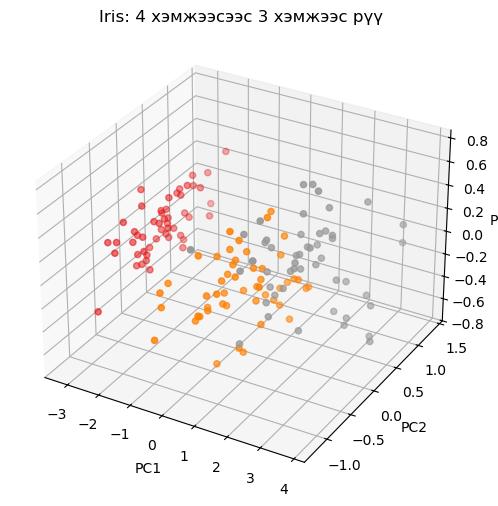

Бүрэлдэхүүн тус бүрийн тайлбарласан хэлбэлзэл: [0.9246 0.0531 0.0171]
Нийт: 0.9948


In [24]:
pca = PCA(n_components=3)
pca.fit(iris.data)
Xp = pca.transform(iris.data)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
ax.scatter(Xp[:, 0], Xp[:, 1], Xp[:, 2], c=iris.target, cmap=plt.cm.Set1)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
ax.set_title("Iris: 4 хэмжээсээс 3 хэмжээс рүү")
plt.show()

print("Бүрэлдэхүүн тус бүрийн тайлбарласан хэлбэлзэл:", np.round(pca.explained_variance_ratio_, 4))
print("Нийт:", round(pca.explained_variance_ratio_.sum(), 4))

Зөвхөн **PC1 дангаараа 92%** хэлбэлзлийг тайлбарлаж байна. Өөрөөр хэлбэл iris-ийн 4
онцлог нь хоорондоо их корреляцтай (дэлбээний урт, өргөн хамт өсдөг) тул бодит "мэдээлэл"
нь нэг л чиглэлд төвлөрсөн байна.

---

## 10. Даалгавар 2: MNIST өгөгдлийг PCA-гаар бууруулан дүрслэх

Даалгавар: *"mnist санг дээрх аргаар бууруулан дүрсэлж харуулна уу"*

MNIST нь 28×28 = **784 хэмжээст** гар бичмэл цифрүүд. Үүнийг 2-3 хэмжээс рүү буулгаж
харцгаая.

In [25]:
from sklearn.datasets import fetch_openml

# Анх татахад хэдэн минут орж болно, дараа нь ~/scikit_learn_data-д кэшлэгдэнэ
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="liac-arff")
Xm_all, ym_all = mnist.data, mnist.target.astype(int)

print("Бүтэн MNIST:", Xm_all.shape)

# Дүрслэл, хурдны үүднээс 10,000 жишээг санамсаргүйгээр авна
rng = np.random.RandomState(42)
idx = rng.choice(len(Xm_all), 10000, replace=False)
Xm, ym = Xm_all[idx] / 255.0, ym_all[idx]      # [0,1] завсарт масштаблах
print("Ашиглах дэд олонлог:", Xm.shape)

Бүтэн MNIST: (70000, 784)
Ашиглах дэд олонлог: (10000, 784)


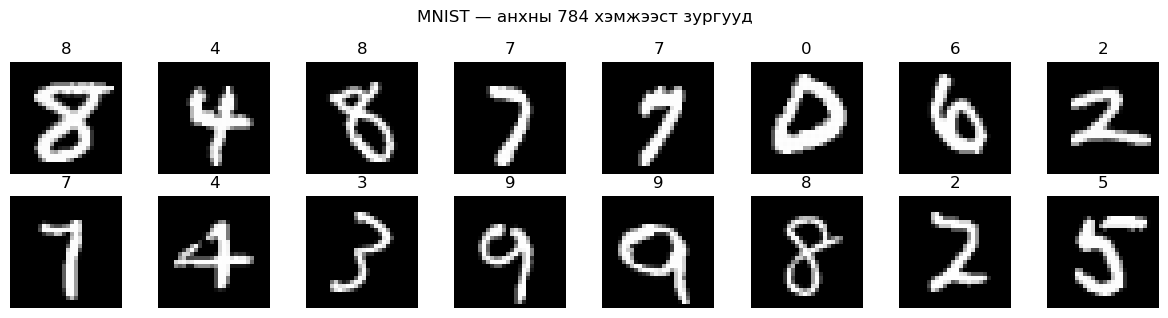

In [26]:
# Анхны зургуудаас хэдийг нь харцгаая
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, i in zip(axes.ravel(), range(16)):
    ax.imshow(Xm[i].reshape(28, 28), cmap="gray")
    ax.set_title(str(ym[i])); ax.axis("off"); ax.grid(False)
plt.suptitle("MNIST — анхны 784 хэмжээст зургууд")
plt.tight_layout(); plt.show()

80% хэлбэлзлийг тайлбарлахад  43 бүрэлдэхүүн хэрэгтэй (784-өөс 5.5%)
90% хэлбэлзлийг тайлбарлахад  86 бүрэлдэхүүн хэрэгтэй (784-өөс 11.0%)
95% хэлбэлзлийг тайлбарлахад 151 бүрэлдэхүүн хэрэгтэй (784-өөс 19.3%)
99% хэлбэлзлийг тайлбарлахад 326 бүрэлдэхүүн хэрэгтэй (784-өөс 41.6%)


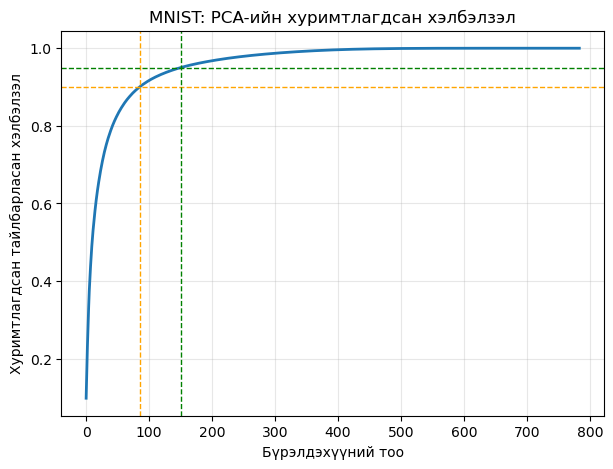

In [27]:
# Хэдэн бүрэлдэхүүн хангалттай вэ?
pca_full = PCA().fit(Xm)
cum = np.cumsum(pca_full.explained_variance_ratio_)

for target in [0.80, 0.90, 0.95, 0.99]:
    k = int(np.argmax(cum >= target)) + 1
    print(f"{int(target*100)}% хэлбэлзлийг тайлбарлахад {k:>3} бүрэлдэхүүн хэрэгтэй "
          f"(784-өөс {100*k/784:.1f}%)")

plt.plot(cum, lw=2)
for target, c in zip([0.90, 0.95], ["orange", "green"]):
    k = int(np.argmax(cum >= target)) + 1
    plt.axhline(target, ls="--", c=c, lw=1)
    plt.axvline(k, ls="--", c=c, lw=1)
plt.xlabel("Бүрэлдэхүүний тоо"); plt.ylabel("Хуримтлагдсан тайлбарласан хэлбэлзэл")
plt.title("MNIST: PCA-ийн хуримтлагдсан хэлбэлзэл")
plt.show()

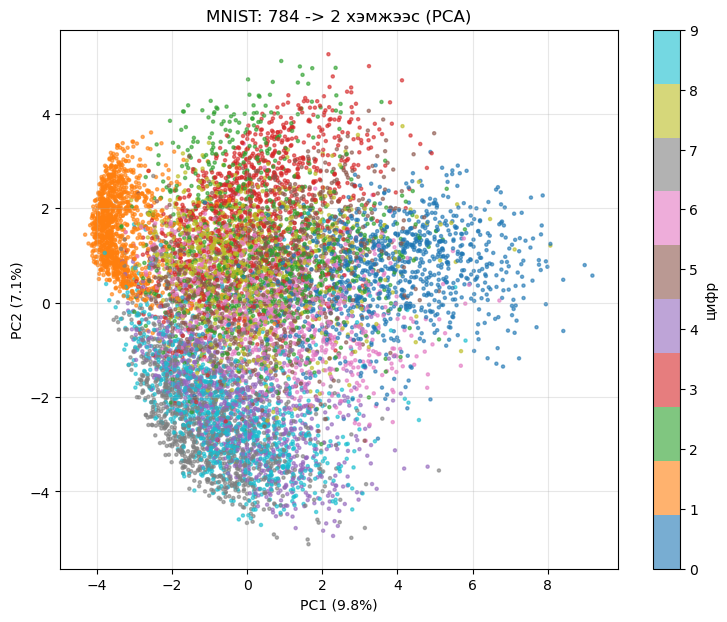

In [28]:
# 2 хэмжээс рүү буулгаж дүрслэх
pca2 = PCA(n_components=2)
Xm2 = pca2.fit_transform(Xm)

plt.figure(figsize=(9, 7))
sc = plt.scatter(Xm2[:, 0], Xm2[:, 1], c=ym, cmap="tab10", s=5, alpha=0.6)
plt.colorbar(sc, label="цифр", ticks=range(10))
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("MNIST: 784 -> 2 хэмжээс (PCA)")
plt.show()

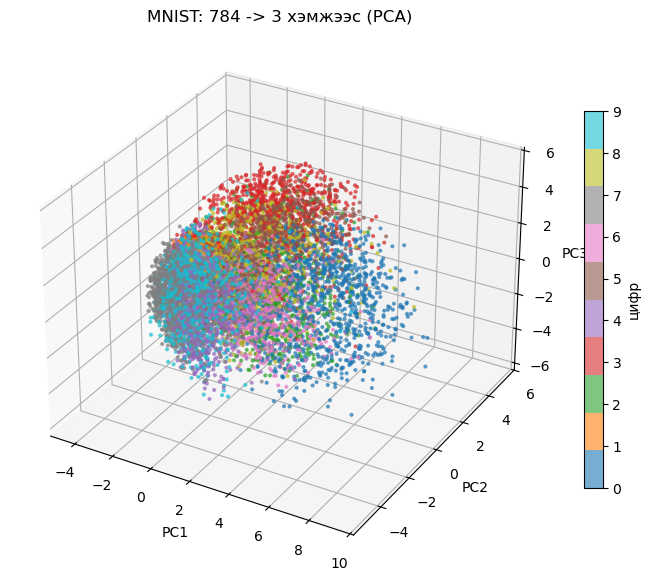

3 бүрэлдэхүүний тайлбарласан хэлбэлзэл: 0.2306


In [29]:
# 3 хэмжээс рүү — iris-тэй ижил аргаар
pca3 = PCA(n_components=3)
Xm3 = pca3.fit_transform(Xm)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection="3d")
p = ax.scatter(Xm3[:, 0], Xm3[:, 1], Xm3[:, 2], c=ym, cmap="tab10", s=4, alpha=0.6)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
ax.set_title("MNIST: 784 -> 3 хэмжээс (PCA)")
fig.colorbar(p, label="цифр", ticks=range(10), shrink=0.7)
plt.show()

print("3 бүрэлдэхүүний тайлбарласан хэлбэлзэл:", round(pca3.explained_variance_ratio_.sum(), 4))

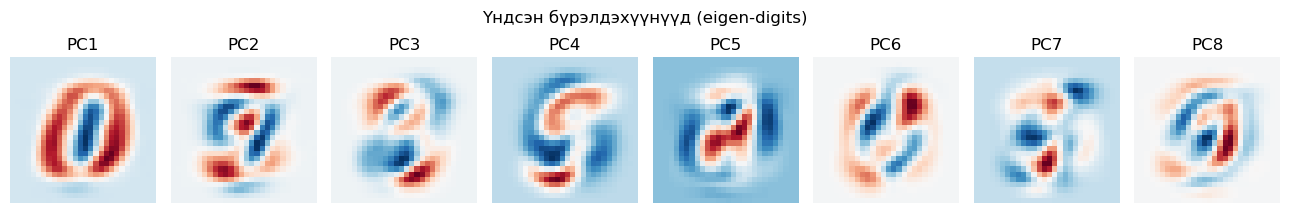

In [30]:
# Эхний 8 бүрэлдэхүүн ямар "хэлбэр" барьж байна вэ?
fig, axes = plt.subplots(1, 8, figsize=(13, 2.2))
for i, ax in enumerate(axes):
    ax.imshow(pca_full.components_[i].reshape(28, 28), cmap="RdBu_r")
    ax.set_title(f"PC{i+1}"); ax.axis("off"); ax.grid(False)
plt.suptitle("Үндсэн бүрэлдэхүүнүүд (eigen-digits)")
plt.tight_layout(); plt.show()

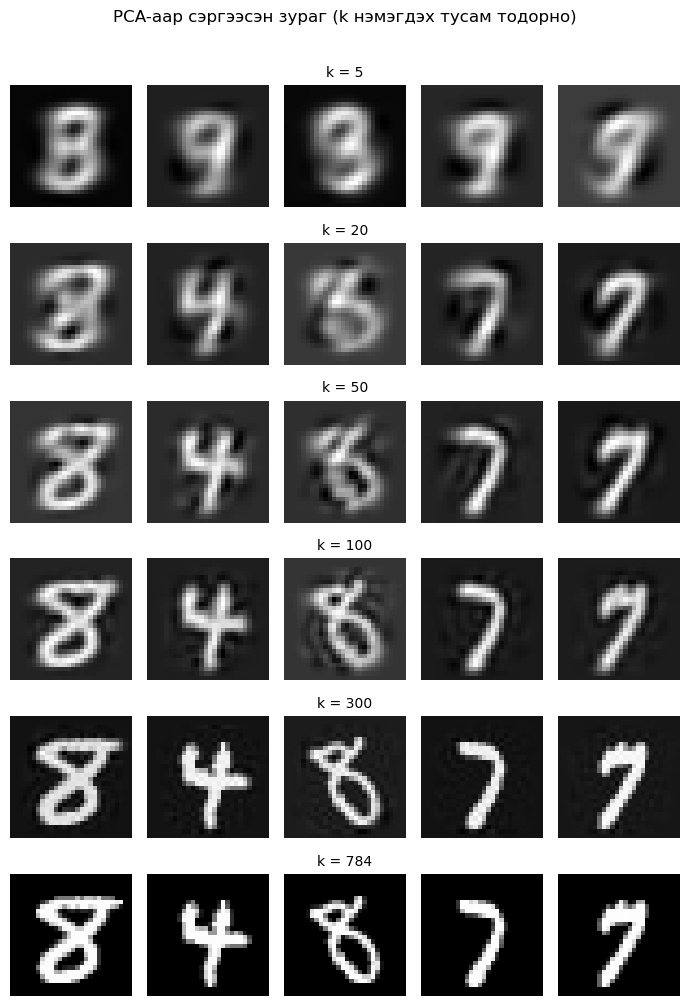

In [31]:
# Хэдэн бүрэлдэхүүнээр зургийг дахин сэргээж болох вэ?
ks = [5, 20, 50, 100, 300, 784]
sample = Xm[:5]

fig, axes = plt.subplots(len(ks), 5, figsize=(7, 10))
for r, k in enumerate(ks):
    p = PCA(n_components=k).fit(Xm)
    recon = p.inverse_transform(p.transform(sample))
    for c in range(5):
        axes[r, c].imshow(recon[c].reshape(28, 28), cmap="gray")
        axes[r, c].axis("off"); axes[r, c].grid(False)
    axes[r, 0].set_ylabel(f"k={k}")
    axes[r, 2].set_title(f"k = {k}", fontsize=10)
plt.suptitle("PCA-аар сэргээсэн зураг (k нэмэгдэх тусам тодорно)", y=1.01)
plt.tight_layout(); plt.show()

In [32]:
# Практик ашиг: PCA-гаар бууруулсны дараа ангилал хийвэл хурд/нарийвчлал хэрхэн өөрчлөгдөх вэ?
import time
from sklearn.model_selection import train_test_split

Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.3, random_state=0, stratify=ym)

rows = []
for k in [None, 50, 100]:
    if k is None:
        A_tr, A_te, label = Xm_tr, Xm_te, "PCA-гүй (784)"
    else:
        p = PCA(n_components=k, random_state=0).fit(Xm_tr)
        A_tr, A_te, label = p.transform(Xm_tr), p.transform(Xm_te), f"PCA (k={k})"

    t0 = time.time()
    clf = LogisticRegression(max_iter=1000).fit(A_tr, ym_tr)
    train_time = time.time() - t0

    rows.append({"Онцлогийн орон зай": label,
                 "Хэмжээс": A_tr.shape[1],
                 "Тестийн нарийвчлал": round(clf.score(A_te, ym_te), 4),
                 "Сургалтын хугацаа (сек)": round(train_time, 2)})

pd.DataFrame(rows)

,Онцлогийн орон зай,Хэмжээс,Тестийн нарийвчлал,Сургалтын хугацаа (сек)
0,PCA-гүй (784),784,0.8863,1.30
1,PCA (k=50),50,0.8880,0.15
2,PCA (k=100),100,0.8993,0.36


### MNIST PCA-ийн дүгнэлт

- 784 хэмжээсийн **95%** хэлбэлзлийг ойролцоогоор **150 орчим** бүрэлдэхүүн барьж байна —
  өөрөөр хэлбэл пиксэлүүдийн дийлэнх нь илүүдэл (хөрш пиксэлүүд бараг ижил утгатай,
  захын пиксэлүүд бараг үргэлж хар).
- 2 хэмжээст зурагт **0, 1, 6** цифрүүд тод тусгаарлагдаж байхад **4, 7, 9** нь хоорондоо
  ихээр давхцаж байна. Энэ нь гар бичмэлээр эдгээр цифрүүд үнэхээр төстэй байдагтай
  нийцнэ. Зөвхөн 2 бүрэлдэхүүн нь нийт хэлбэлзлийн ~17% л барьдаг тул ийм давхцал
  хүлээгдэж буй зүйл.
- Сэргээлтийн зурагнаас: k=5 үед зөвхөн бүдэг толбо, k=50 үед цифр танигдана, k=300 үед
  нүдээр бараг ялгагдахгүй. Өөрөөр хэлбэл 300 тоогоор 784 пиксэлийг илэрхийлж чадаж байна.
- Практик ач холбогдол: PCA(k=100) нь нарийвчлалыг бараг алдалгүй сургалтын хугацааг
  мэдэгдэхүйц богиносгож байна. Энэ нь PCA-г зөвхөн дүрслэлд биш, **урьдчилсан
  боловсруулалтад** ашигладгийн шалтгаан.

---

## 11. Лабораторийн нэгдсэн дүгнэлт

1. Логистик регрессийг sigmoid → cross-entropy → gradient descent гэсэн гурван бүрэлдэхүүнээс
   NumPy дээр бүрэн эхнээс нь хэрэгжүүлж, sklearn-тэй ижил үр дүн авав.
2. Алдагдлын муруй ба суралцах хурдны туршилтаас $\alpha$ нь нийлэлтийн хурдыг шууд
   тодорхойлдог болохыг харлаа.
3. Логистик регрессийн шийдвэрийн хязгаар нь **шугаман** — өгөгдөл анги тус бүр олон
   бөөгнөрөлтэй үед энэ нь гол хязгаарлалт болж байна.
4. Titanic дээр нарийвчлал ~0.78–0.80, AUC ~0.85 гарсан ба коэффициентүүд нь Лаб 2-ын
   perceptron-ы жингүүдтэй ижил зүй тогтол (хүйс, зэрэглэл) харуулав.
5. PCA нь iris-ийн 4 хэмжээсийн 92%-ийг нэг бүрэлдэхүүнээр, MNIST-ийн 784 хэмжээсийн
   95%-ийг ~150 бүрэлдэхүүнээр барьж чадаж байна — бодит өгөгдлийн "жинхэнэ хэмжээс"
   нь нэрлэсэн хэмжээснээсээ хамаагүй бага байдаг.